#  연관분석

## 연관 분석의 정의
- ##### 상품이나 서비스를 구매하는 등 일련의 거래나 사건 안에 존재하는 **항목 간의 일정한 연관 규칙을 발견하는 분석**
- 장바구니 분석이라고도 하나, 엄밀히 말하면 장바구니 분석은 유통업에서 부르는 용어이며, 연관 분석의 한 분야

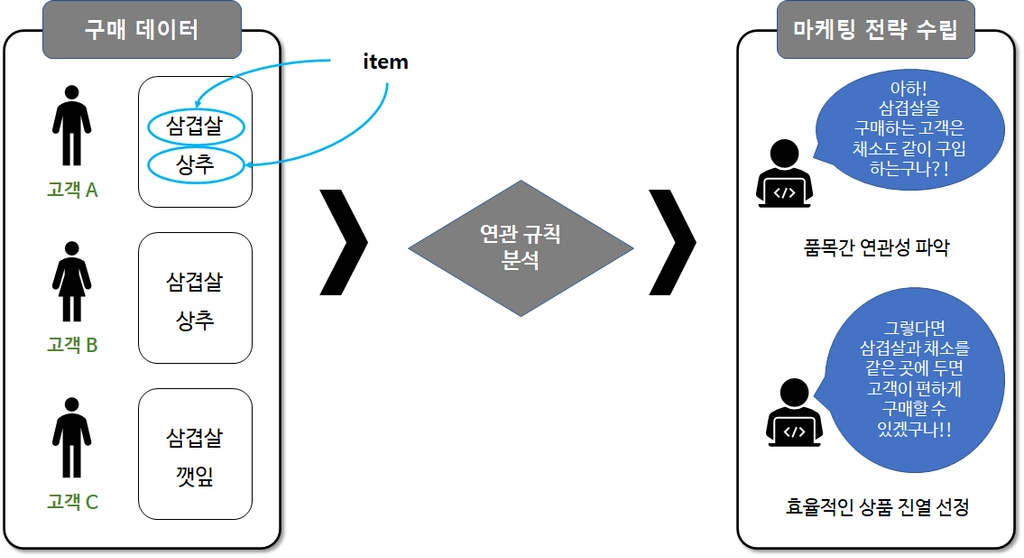
- 상품 거래에만 사용되는 것이 아니라, 의사의 질병 진단 등 타 분야에서도 폭넓게 사용
- 정답 값이 별도로 존재하지 않는 **비지도 학습**

## 연관규칙 분석
- ‘A를 구매하였을 때, B 또한 구매할 것이다’와 같이 if-then 의 형식을 띄고, A→B으로 표현

- **조건절(Antecedent):** `만일 ~라면`에 해당하는 부분
- **결과절(Consequent):** 그 뒷부분에 해당하는 내용
- **아이템 집합(Item set):** 조건절 또는 결과절을 구성하는 아이템들의 집합

> ##### `라면을 구매`하는 사람들은 `달걀도 함께 산다.`

- `라면 구매` 가 조건절, `달걀 구매` 가 결과절
- 각각의 아이템 집합은 `라면` `달걀`
- 아이템 집합은 말 그대로 집합, 여러 개 아이템이 들어가도 되지만 상호 배반(mutually exclusive)이어야 함
    <details>
    <summary>예시</summary>

    * **맥주**를 구매하는 사람은 **기저귀, 분유**를 함께 구매한다.
    * **샌드위치**를 먹는 사람은 **탄산수**를 함께 마신다.
    * **사탕, 모자**를 구매하는 사람은 **키보드**를 함께 구매한다.

    </details>

# 주요 개념

## 연관규칙의 조건
1. 두 품목(품목 A와 B)이 함께 구매한 경우의 수가 일정 수준 이상이어야 한다. 
(**일정 이상의 지지도**)
2. 품목 A를 포함하는 거래 중 품목 B를 구입하는 경우의 수가 일정 수준 이상이어야 한다. 
(**일정 이상의 신뢰도**)

> ### 지지도 (Support)
- ##### 전체 거래항목 중 품목 A와 품목 B가 동시에 포함하는 거래의 비율

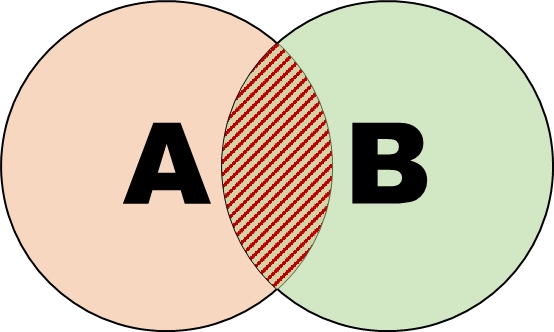
$$
지지도 = P(A \cap B)
$$

즉, ‘이 규칙이 현실에서 의미 있는가?'를 판단하는 가장 1차적인 기준

> ### 신뢰도 (Confidence)
- ##### 품목 A를 포함하는 거래 수 중 품목 A와 품목 B가 동시에 포함하는 거래의 비율

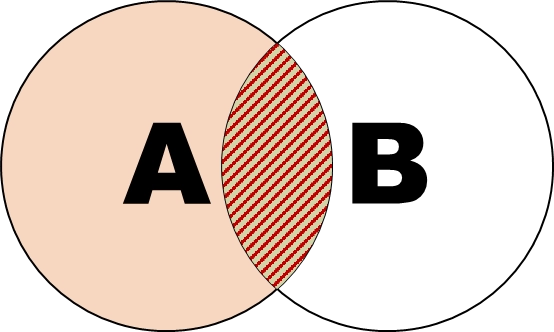
$$
신뢰도 = \frac{P(A \cap B)}{P(A)} = \frac{지지도}{P(A)}
$$

## 연관 분석의 평가 측도
> ### 향상도 (Lift)
- ##### 품목 A가 주어지지 않았을 때의 품목 B의 확률 대비,
    ##### 품목 A가 주어졌을 때의 품목 B의 확률의 증가 비율
- 핵심 아이디어는 "A와 B가 우연히 함께 등장할 확률과 실제 함께 등장할 확률을 비교하자.”

$$
향상도 = \frac{P(A \cap B)}{P(A)P(B)} = \frac{신뢰도}{P(B)}
$$

>> 1. **독립일 때 기댓값**
- 확률에서 사건 A와 B가 **독립**이라면: 
    - $P(A∩B)=P(A)⋅P(B)$
    - 즉, A를 샀다는 사실이 B를 살 확률에 **영향을 주지 않는다**는 뜻
    - 향상도는 1이 됨
        
        $$
        향상도 = \dfrac{P(A∩B)}{P(A)⋅P(B)} = \dfrac{P(A)⋅P(B)}{P(A)⋅P(B)}=1
        $$
        
- 확률에서 사건 A와 B가 **독립이 아니라면**:
    - $P(A∩B)=P(A)⋅P(B∣A)=P(B)⋅P(A∣B)$
    - 즉, A를 샀다는 사실이 B를 살 확률에 **영향을 주**거나,
    B를 샀다는 사실이 A를 살 확률에 **영향을 준다**는 뜻
    - 실제로 관측한 $P(A∩B)$에 따라 향상도는 1보다 크거나, 1보다 작음
>> 2. **실제 동시 발생 확률**
- 우리가 **실제로 관측한 $P(A∩B)가**,
    
    **A와 B가 함께 등장할 확률의 기댓값** $P(A)\cdot P(B)$**보다** 
    
    - **크면 → 양의 연관성** (A 사면 B도 잘 삼)
    - **작으면 → 음의 연관성** (A 산 사람은 B 잘 안 삼)
>> 3. **비율로 비교 → 향상도**


| 향상도 > 1 | 우연적 기회보다 **높은** 확률 (두 품목이 서로 **양의 상관관계**) |
| --- | --- |
| 향상도 = 1 | 독립 |
| 향상도 < 1 | 우연적 기회보다 **낮은** 확률 (두 품목이 서로 **음의 상관관계**) |
---
- 규칙의 효용성은 지지도, 신뢰도, 향상도 세 가지를 **모두 반영해 평가**
- 임의의 규칙1이 규칙2보다 효과적인 규칙이라는 이야기를 하려면 
**세 지표 모두 클 경우에만 그렇다고 결론을 내릴 수 있게 된다**

# 연관 분석 알고리즘

## Apriori 알고리즘
- ##### 선험적 경험을 이용 (A Priori)

> ### 배경: 무차별 탐색의 비효율
- 연관 규칙을 찾기 위해 **가능한 모든 조합**을 시도하는 것은 매우 **비효율적**
    - **가능한 모든 조합** : **`A(선행조건) → B(결과조건)`** 로 표현되도록 하는 모든 경우의 수
    - 이때 A, B는 단일 품목이 아니라 여러 품목으로 구성된 복합 조건이 될 수 있음
- 상품의 개수가 많아질수록 조합의 수가 기하급수적으로 증가

> ### Apriori 알고리즘 소개
- ##### 상위 조합에서부터 차례로 스캔하면서 특정 조합이 자주 발생하지 않는다면 이의 결과물로 탄생한 후속 조합들까지 모두 후보에서 **배제**하는 방식의 알고리즘
- **장점:** 
    - Apriori 알고리즘을 활용하면 하나의 조합만 검사하고도 이에서 파생된 다른 조합들까지 후보에서 배제할 수 있게 되므로 시간과 연산량을 효과적으로 줄일 수 있음
    
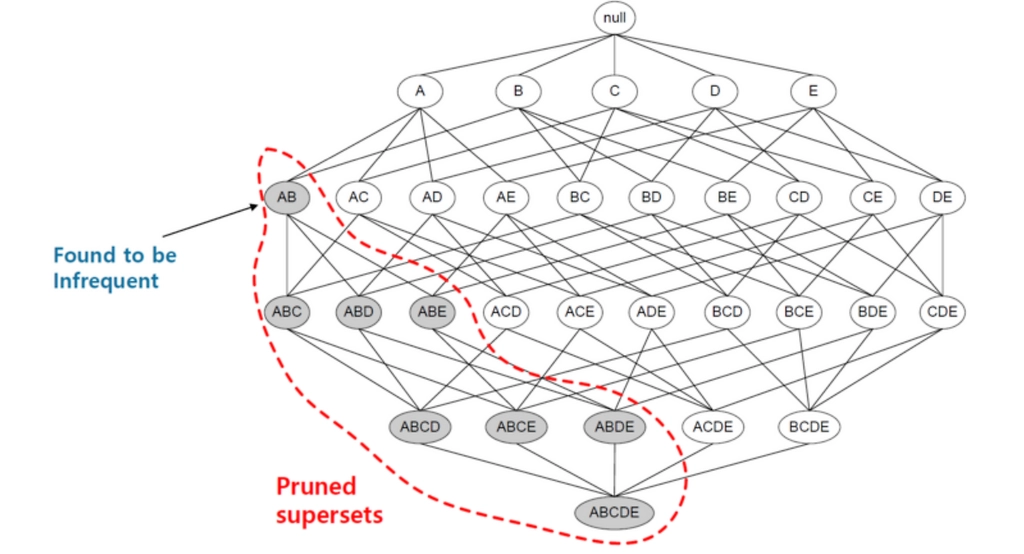

- 집합 `{A,B}` 의 지지도가 사용자가 정한 **최소 지지도를 넘지 못하면**, `{A,B}` 를 포함한 `{A,B,C}`,`{A,B,D}` 등의 규칙들도 **모두 한번에 제거**
- -> **연산량 감소**

> ### Apriori 알고리즘 프로세스
- ##### **빈발 항목 집합**을 찾고 → 단계적으로 조합을 생성하고 필터링
- **빈발 항목 집합** : 일정한 최소 지지도를 넘는 항목들의 조합
---
>> 1. **단일 항목 집합 생성**

1. 모든 개별 상품에 대해 지지도를 계산한다.
2. **최소 지지도**를 넘는 항목들만 다음 단계로

>> 2. **2개 항목 집합 생성**

1. 1단계에서 선별된 상품들로 2개 항목의 조합을 만든다.
2. 이 조합에 대해 지지도를 계산하고, 최소 지지도를 넘지 않는 조합을 **제거**

>> 3. **더 큰 항목 집합 생성**

1. 이전 단계에서 남은 조합들을 바탕으로 3개 이상의 항목으로 구성된 조합을 만든다.
2. 지지도를 계산하고, 최소 지지도를 넘지 않는 조합을 **제거**
3. 더 이상 조합을 생성할 수 없을 때 까지 이 과정을 반복

>> 4. **최종 빈발 항목 집합 선정**

1. 마지막으로 남은 빈발 항목 집합들을 바탕으로 **연관 규칙**을 생성한다.
2. 각 규칙에 대해 지지도, 신뢰도, 향상도를 계산하여 가장 유용한 규칙을 선택


> ### Apriori 알고리즘의 장단점
- ##### 장점
    - 수많은 상품 연관 구매 패턴 발견
    - 원리가 간단하고, 이해분석이 용이
- ##### 단점
    - 여전히 데이터가 커질수록 속도 감소

> ### Apriori 알고리즘 코드
```python
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# 최소 지지도를 설정하여 자주 함께 구매되는 상품 조합을 찾기
frequent_itemsets = apriori(df, min_support=0.06, use_colnames=True)

# 연관 규칙을 추출하고, 신뢰도 0.8 이상의 규칙만 추출
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.8)

# 향상도를 기준으로 내림차순 정렬하여 상위 규칙을 확인
top_rules = rules.sort_values(by='lift', ascending=False).head()
```

## FP Growth 알고리즘
- ##### Apriori의 연산 속도 문제를 해결할 수 있게 자료구조를 잘 이용한 알고리즘
> ### 배경 : 여전히 느리다

- Apriori 알고리즘은 여전히 **데이터가 커질수록 속도가 느려진다**는 단점 존재
    - 각 단계에서 데이터를 다시 스캔해야 하기 때문

> ### FP-Growth 알고리즘 소개

- FP-Growth (Frequent Pattern Growth) 알고리즘은 빈발 품목 집합을 효율적으로 찾아냄
- **FP-Tree** 라는 구조를 이용하여 Apriori를 효과적으로 구현
- Tree, Array, Linked_List를 합쳐놓은 구조
    
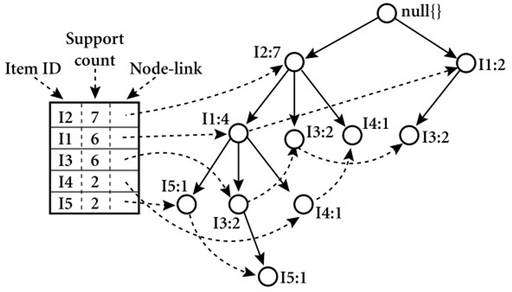
    
- **모든 거래를 확인해 각 아이템마다 지지도를 계산하고, 최소 지지도 이상의 아이템만 선택**
    - 모든 거래에서 빈도가 높은 아이템 순서대로 순서를 정렬
    - 부모 노드를 중심으로 거래를 자식 노드로 추가해주며 **tree 를 생성**
    - 새로운 아이템이 나올 경우 부모노드부터 시작하고, 그렇지 않으면 기존의 노드에서 확장
    - 위의 과정을 모든 거래에 대해 반복하여 FP Tree 를 만들고 **최소 지지도** 이상의 패턴만 추출

> ### FP-Growth 알고리즘 프로세스
- 모든 항목의 빈도를 계산한 후, **최소 지지도 이상인 항목만**을 남긴다.

>> 1. **데이터셋 확인**
- 예시 :
    
    $$
    D = [ \{초장\}^9, \{과메기\}^{40}, \{과메기, 김\}^{50}, \{과메기, 김, 초장\}^1] 
    $$
    
    초장만 산 사람이 9명
    과메기만 산 사람이 40명
    과메기와 김을 함께 산 사람이 50명
    과메기, 김, 초장을 모두 함께 산 사람이 1명
    
>> 2. **빈도순 재정렬**

- 남은 항목들을 **각 거래별로 빈도순으로 재정렬**한다. 
- 거래 데이터에서 **가장 자주 구매된 항목이 먼저 오도록 재정렬**한다.

- 이를 f-list 라고 한다. : 과메기-김-초장

- 예시 :
    
    ① 과메기 : 91

    ② 김: 51
   
    ③ 초장 : 10

>> 3.  **FP-트리 생성**

- 재정렬된 데이터를 바탕으로 **FP-트리를 생성**한다. 
-  트리는 **각 거래**를 **노드**로 표현하며, 
- **동일한 항목**은 **기존 노드에 연결**해 **빈도를 증가**시키고, 
- **새로운 항목**은 **새로운 노드로 추가**가까운 node가 된다.

>> 4. **빈발 항목 집합 추출**

- **FP-트리를 바탕**으로 **특정 항목을 기준으로 부분 트리**를 만들어 **빈발 항목 집합을 추출**
- 이 부분 트리에서는 기준이 된 항목과 연관된 빈발 항목 집합을 **빠르게 도출** 가능

>> 5. **연관 규칙 도출**

- FP-트리에서 도출된 빈발 항목 집합을 바탕으로 **연관 규칙**을 만든다. 
- 각 규칙에 대해 **지지도(Support), 신뢰도(Confidence), 향상도(Lift)** 등의 지표를 계산해 **가장 유용한 규칙을 선택**
- 예시 : 자주 함께 구매되는 패턴을 발견하여, 이들 간의 연관 규칙을 도출해 묶음 판매 전략 수립

> ### FP-Growth 알고리즘의 장단점
- ##### **장점**
    - 데이터를 두 번만 스캔하는 Tree 구조이기 때문에 Apriori보다 훨씬 **빠름**
    - 후보 Itemset을 생성할 필요 없이, Tree만 구성하면 끝

- ##### **단점**
    - 대용량 데이터셋에서 메모리를 효율적으로 사용하지 않음
    - Apriori에 비해 설계하기 어렵고, 지지도의 계산은 무조건 FP-Tree가 만들어져야 함
    
> ### FP-Growth 알고리즘 코드

```python
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# 최소 지지도를 0.06으로 설정하여 빈발 항목 집합을 찾기
frequent_itemsets = fpgrowth(df, min_support=0.06, use_colnames=True)

# 연관 규칙을 추출하고, 신뢰도 0.8 이상의 규칙만 추출
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.8)
```

---
# 경영 기초

# 문제 정의와 구조화

## 문제 정의
- ##### 문제: 현재의 상태 (Current State)'와 '바라는 상태(Desired State)' 사이의 격차(Gap)
- **현상(Symptom) vs 문제(Problem):**
    - **현상** : “매출이 전월 대비 10% 감소했다” (관찰된 사실)
    - **문제** : “감소한 매출을 회복하기 위해 어떤 세그먼트를 공략해야 하는가?’ (해결해야 할 질문)
- 핵심 : 단순히 나쁜 상황을 나열하는 것은 문제가 아님 → **경영자가 ‘의사결정’을 내려야 하는 구체적인 질문으로 치환되었을 때 비로소 ‘문제’가 됨**

> ### SMART 원칙
- 문제를 보다 쉽고 정교하게 정의하기 위한 원칙

| **SMART 원칙** | **특징** | **의미** |
| --- | --- | --- |
| **S**pecific | 구체적이고 범위가 명확함 | 무엇을, 어디까지 풀지 명확하게 정의 |
| **M**easurable | 수치로 측정 가능함 | 성공 여부를 숫자로 판단 가능 |
| **A**ction-oriented | 실행 지향적 / 결과 중심적 | 행동을 이끌어내고 성과에 집중함 |
| **R**elevant | 관련성 | 조직의 목표와 관련이 있어야 함 |
| **T**ime-bound | 시한성 (Time-bound) | 마감 기한과 의사결정 시점이 존재함 |

## 문제 구조화
- ##### **문제를 정의했다면**..이를 해결 가능한 하위 문제(Sub-issues)들로 분해해야 함. 아래의 두 가지 도구를 사용

> ### MECE
- MECE 는 문제를 쪼갤 때 반드시 지켜야 할 철칙
- **Mutually Exclusive (상호 배타적):** 겹치는 부분이 없어야 함 (중복 방지)
- **Collectively Exhaustive (전체 포괄적):** 누락된 부분이 없어야 함 (누락 방지)
>> 예시
- **생물학적인 성 구분**: 남성/여성
- **소비자를 나이대로 구분**: 0~15세 미만, 15~30세 미만, 30~50세 미만, 50세~70세 미만, 70세 이상
- **(나쁜 예시) 소비자를 구분**: 남성/여성/직장인/학생
>> 좋은 MECE를 하기 위한 몇 가지 규정
1. **논리적 일관성:** 한 층위에서는 **하나의 기준**으로만 나눠야 함
2. **통찰력:** 문제를 해결하는 데 도움이 되는 기준으로 나눠야 함
3. **상호 배타성 (Mutually Exclusive)**: 조각들이 서로 겹치지 않아야 분석 결과가 명확

# 지표

## 지표
- ##### 방향이나 목적, 기준 따위를 나타내는 표지. 추상적인 개념과 관련되는 지수, 척도 등을 말하며 측정하고 싶은 것을 숫자로 표현한 것
$$

\text{metrics} = \frac{\text{numerator}}{\text{denominator}}

$$

- 위와 같이 대게 지표는 분모 대비 분자로 표현

| 유형 | 공식 구조 | 예시 지표 |
| --- | --- | --- |
| 효율성(Efficiency) | 산출 / 투입 | 노동생산성 = 생산량 / 노동시간 |
| 효과성(Effectiveness) | 달성 결과 / 목표 | 목표 달성률 = 실제 매출 / 목표 매출 |
| 수익성(Profitability) | 이익 / 자원 | ROE = 순이익 / 자기자본 |
| 성장성(Growth) | 증가분 / 기존 규모 | 매출 성장률 = (당기매출-전기매출) / 전기매출 |
| 안정성(Stability) | 보유자산 / 부채 | 부채비율 = 부채 / 자기자본 |

- 경영학의 기능별로 정리

| 기능 | 효율성 지표 (Output ÷ Input) | 효과성 지표 (Actual ÷ Target) | 수익성/가치 지표 (Profit ÷ Resource) | 성장성/안정성 지표 |
| --- | --- | --- | --- | --- |
| 재무 | 자산회전율 = 매출액 ÷ 총자산 | 예산 집행률 = 실제 지출 ÷ 계획 지출 | ROE = 순이익 ÷ 자기자본ROA = 순이익 ÷ 자산 | 매출 성장률, 부채비율 |
| 마케팅 | CAC 효율 = 신규고객 수 ÷ 마케팅비 | 전환율 = 구매자 ÷ 방문자 | 마케팅 ROI = 캠페인 이익 ÷ 캠페인 비용 | 시장점유율 성장률 |
| HR (인사) | 노동생산성 = 산출량 ÷ 인력투입 | 교육 효과 달성률 = 실제 역량향상 ÷ 목표 역량향상 | HR ROI = 교육 후 성과 증가 ÷ 교육비 | 이직률, 직원 유지율 |
| 운영 | 설비가동률 = 실제 가동시간 ÷ 총 가능시간 | 품질목표 달성률 = 합격품 ÷ 목표 품질수준 | 단위당 원가 절감율 = 절감액 ÷ 총원가 | 재고회전율, 공급망 안정성 |

## 지표 정의하기
> ### Proxy Metric
- ##### 활성화와 인게이지와 같이 추상적이여서 프로덕트마다 나름의 가정과 정의, 논의가 필요한 지표

- 궁금하지만 직접 측정할 수 없으니 대체물(Proxy)을 정하여 측정한다는 의미로, Proxy 지표들은 설정 자체에 많은 논의가 필요하고 정답이 별도로 존재하지 않음

> ### 북극성 지표 L1/L2 Metrics
- **북극성 지표:** 기업이 가장 중요하게 생각하는 지표
    - e.g. 에어비엔비 - 예약된 박 수, 페이스북 - DAU

- **L1 / L2 지표:**

    - L1: 전사적인, 고수준의 성과 지표(전략 관점)
    - L2: L1 지표의 세부 사항을 측정하는 지표(전술 관점)

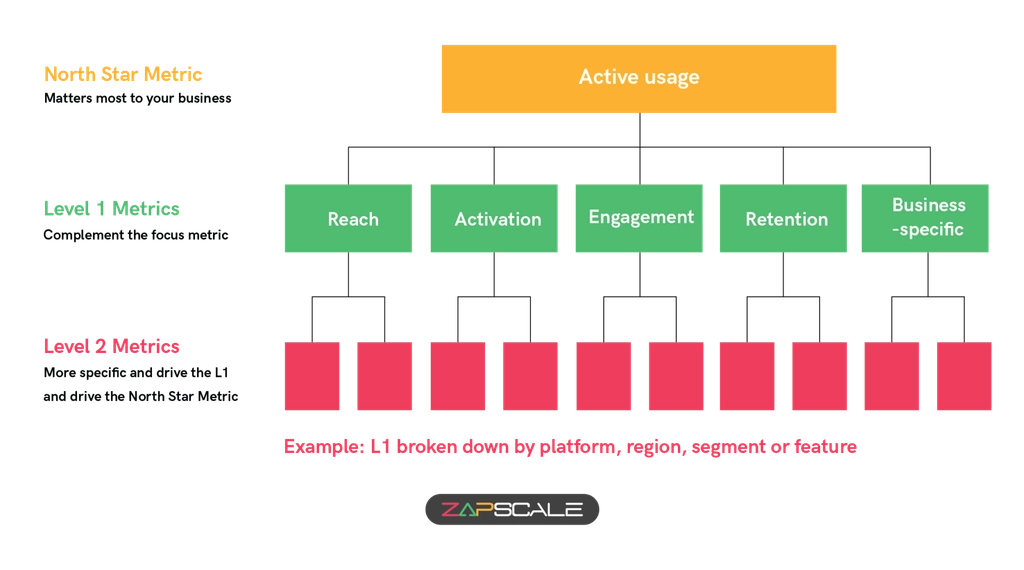

> ### AARRR (해적 지표)
- 넷플릭스, 유튜브, 스포티파이
    - 컨텐츠 감상 시간이 중요한 지표
    - 오래 감상할수록 광고 수익, 유저 리텐션 등에 좋은 영향을 끼치므로
- 우버
    - 공급자와 수요자를 매칭하는 서비스
    - 택시를 부르는 사람들의 요청 중 몇 퍼센트가 실제로 매칭되는지가 중요함
    
    **→프로덕트가 가치를 제공하는 방식이 다르면, 측정하는 지표도 달라져야 함**

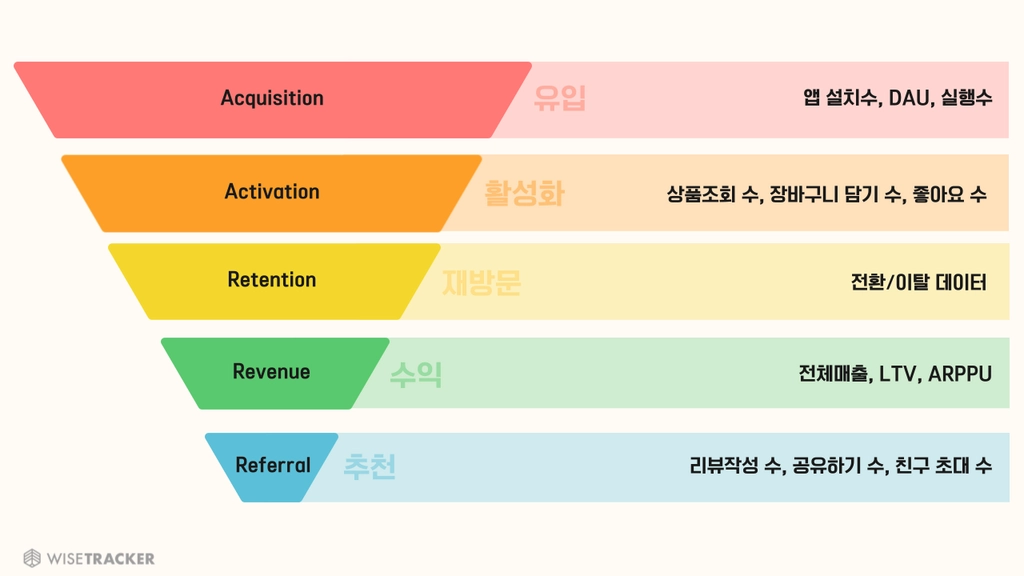
- AARRR 모델 또는 해적지표는 사용자 운영 과정에서 자주 활용하는 데이터 분석 모델로, 사용자 증가를 위한 5가지 로드맵을 구성

>> 1. Acquisition
- Acquisition은 사용자 획득, 즉 사용자가 여러 채널을 통해 여러분의 앱 혹은 웹사이트에 방문하는 것을 의미
- 고객이 유입되는 채널은 광고, 검색엔진 최적화(SEO), 지인 추천, 오프라인 행사 등 매우 다양
- 이 단계에서 고민해야 하는 포인트는, ‘신규 고객을 어떻게 획득할지’, ‘어디로부터 획득할지’, ‘주로 어떤 채널을 통해 획득할지’
- 어떤 제품인지에 따라 고객 획득을 측정하는 기준이 달라지지만, 대체로 조회수, 가입 사용자 수 등 지표를 통해 측정
>> 2. Activation

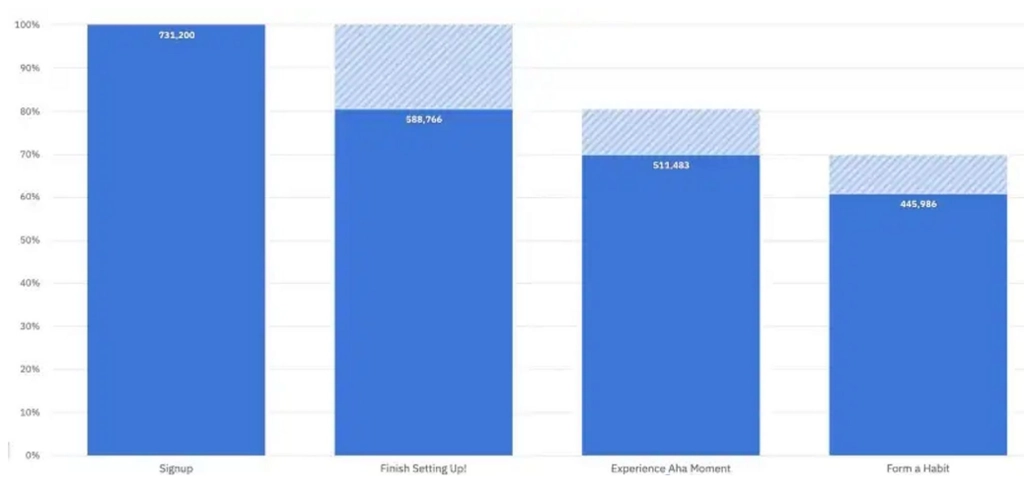

- Activation, 사용자 활성화란 사용자가 앱 또는 웹사이트에 첫 방문하여 주요 기능을 직접 사용하는 것을 의미
- 사용자 활성화는 제품의 성격에 따라 다양한 기준으로 측정
- 기타 측정 지표로는 제품 핵심 기능의 활용도, 사용자의 온라인 접속 시간 등
>> 3. Retention
- Retention, 유지 단계에서는 신규 사용자를 장기 사용자로 전환시키는 것에 초점
- 신규 사용자를 획득하는 데는 기존 사용자를 유지시키는 것 보다 훨씬 많은 비용이 들어가기 때문
- 이 단계에서는 어떻게 장기 고객을 양성할 것인지, 또 어떻게 고객의 지속적인 구매 행위를 증가시킬 수 있을지 고민해봐야 함
- 측정 지표에는 익일 유지율, 1주차 유지율, 2주차 유지율, 월 유지율, EDM 메일 개설율 등
>> 4. Revenue
- Revenue, 수익 단계에서는 사용자가 여러분의 제품 혹은 서비스를 유료 구매하기로 결정한 단계
- 이 단계에서는 사용자의 소비를 유도해 매출을 높이는데 총력
- 최대한 사용자를 소비하게끔 만들거나 매출을 늘릴 수 있는 행위를 하도록 유도
- 측정 지표는 성격에 따라 달라짐
- 고객의 평생 가치(LTV)를 지속적으로 높여 나가고, 고객 유치 비용은 계속해서 줄여나가야 한다는 것이 중요
>> 5. Referral
- 이 단계는 제품의 지속적인 성장을 위한 매우 중요한 단계로, ‘어떻게 충성도 높은 사용자를 보이지 않는 브랜드 홍보자로 만들 것’이며, 또 ‘어떻게 제품을 잠재 고객들에게 추천하도록 만들 것’인가를 고민해봐야 함
- 측정 지표는 ‘순 추천고객 지수(NPS)’, ‘바이럴 지수(Viral Coefficient): 이는 브랜드에 대한 고객의 만족도와 사용자가 평균적으로 추천하는 고객의 수를 뜻함

# 지표 분석 방법

## 코호트 (Cohort)  분석
- ##### **코호트(Cohort)**: 동질 집단
    - **정의된 시간 범위** 내에서 **공통된 특성이나 경험을 공유**하는 사용자 집단을 의미
    - 즉, ‘특정 기간에 특정 특성을 공유하는 사용자 집단’이 **코호트**이며, 이를 분석하는 것이 **코호트 분석**
- 분석 전에 데이터 세트의 데이터를 관련 그룹으로 나누는 일종의 행동 분석
- 시간(날짜)에 기반하는 사용자 세그먼트를 분류한다고 이해
    - ex) 날짜, 시간, 성별 등
- 주로 사용자 유지와 이탈을 체크하는 데 많이 사용
    - ex) 리텐션(ex. 재구매율)

> ### 코호트 분석 해석 방법

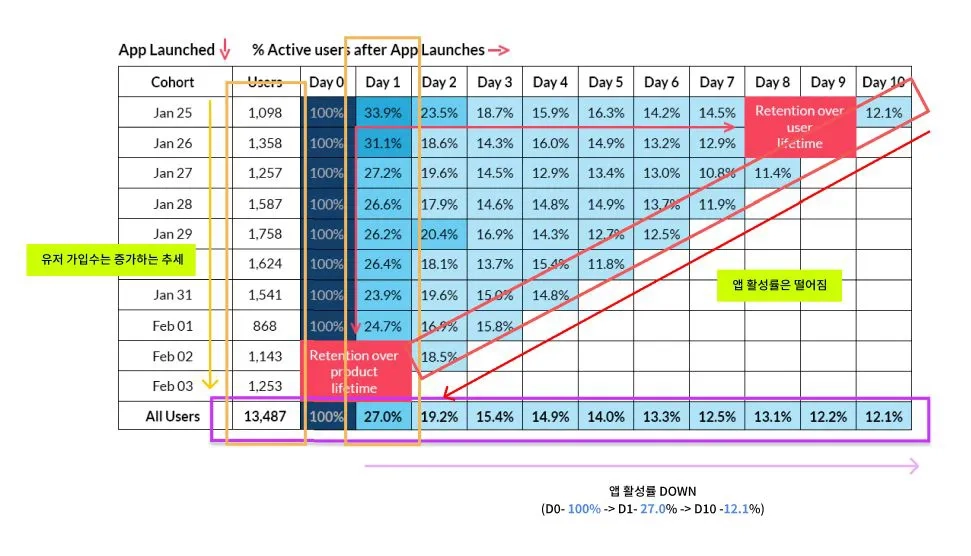

- **세로축(노란색) 방향: 코호트별 비교**
    - 같은 기간이 지난 후 cohort 간 리텐션을 비교할 수 있음
        - ex) 신규 유저 가입자는 점점 증가하는 추세
- **대각선(빨간색) 방향: 시점별 비교**
    - ex) [다른 예시] 2023년 3월부터 2024년 1월까지 보았을 때, 전반적인 고객들의 구매율이 점점 떨어지고 있음을 확인할 수 있음.

    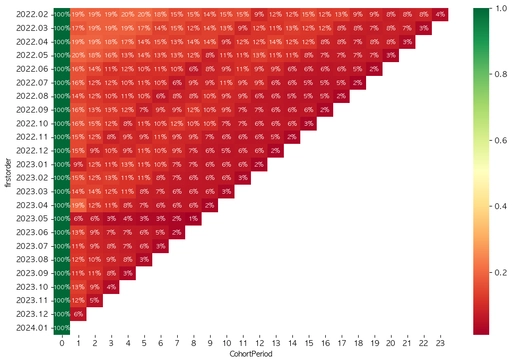

- **가로축(보라색) 방향: 시간의 경과에 따른 변화 관찰**
    - ex) 첫 방문(가입) 이후 시간이 경과할수록 앱 활성률은 떨어짐

- 가입자는 느는데, 사람들이 잘 안 쓰네?
    
    : **Acquisition**은 잘 작동하는데 **Activation&Retention**의 문제임을 알 수 있음

> ### 퍼널 (Funnel) 분석
- 유저가 접속해서 떠날 때까지 유저의 행동을 추적
- 소위 ‘깔때기’라고 불리며, 아래로 갈수록 점점 좁아짐
(시간이 지날수록 유저들은 이탈하기 때문)

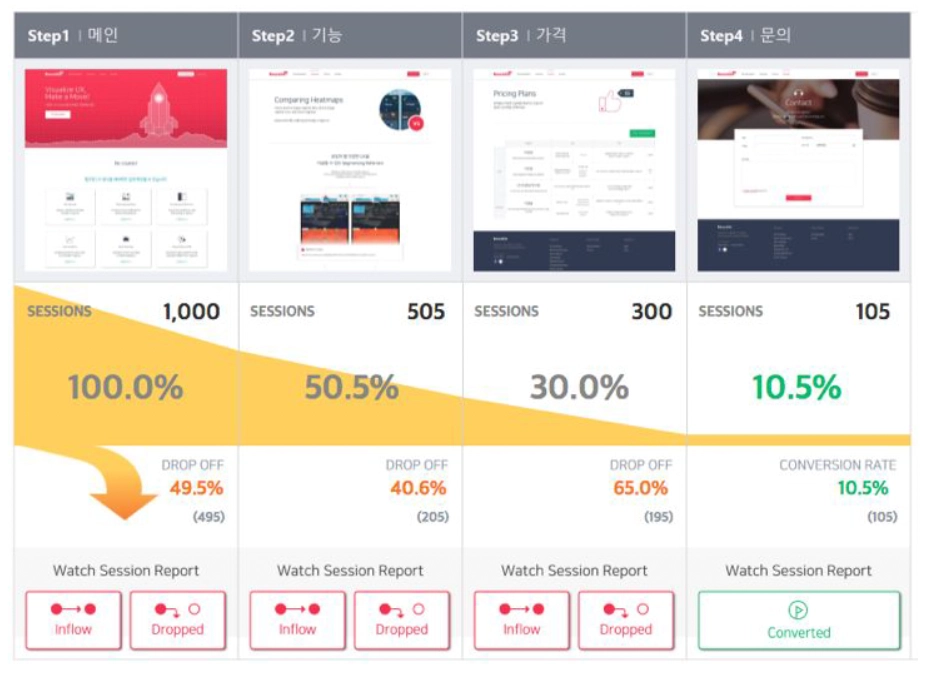

>> 개선 방법
1. 유입률(Acquisition) 높이기
2. 전환율(Activation) 높이기
3. 퍼널 단계 없애기
4. 퍼널 순서 바꾸기
5. 퍼널 단계 추가하기
6. 코호트로 나누어 보기

<details>
<summary>예시</summary>

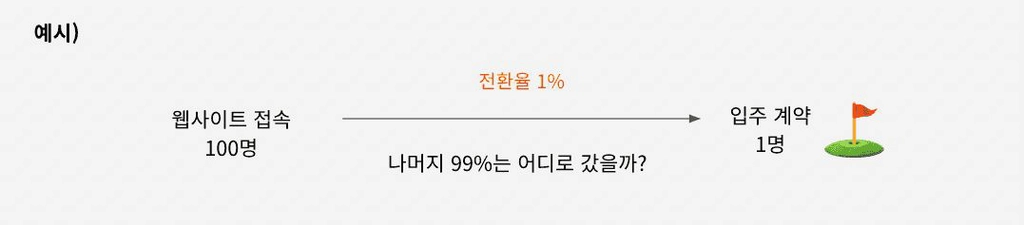

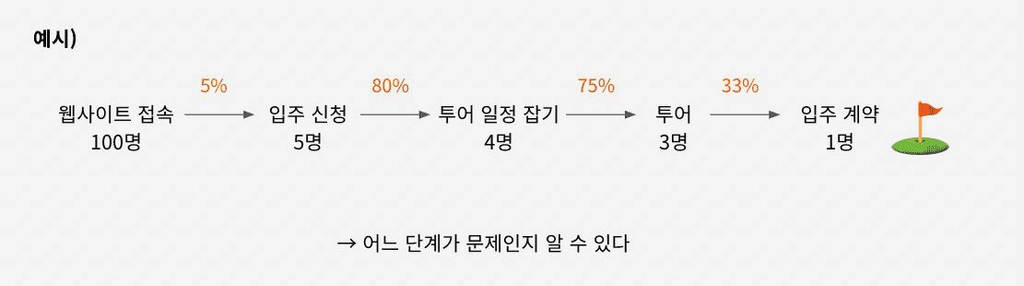

1. 스타트 지점에 있는 사람 늘리기 (Acquisition)

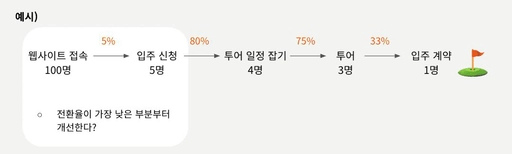

2. 전환율 높이기 (Activation&Retention)

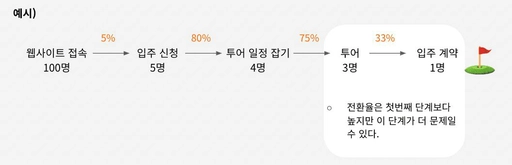

3. 코호트 분석마다 분류하기(집단마다 성향이 다름)

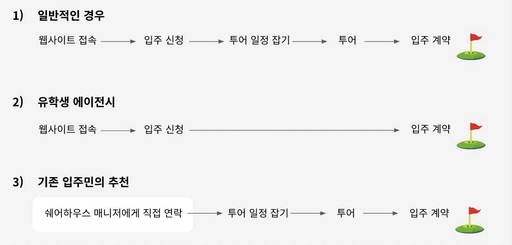

</details>